In [1]:
import numpy as np
import pandas as pd
from sklearn import datasets, ensemble
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.utils.fixes import parse_version
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
%matplotlib inline
import matplotlib.pyplot as plt

"""
Load the days, add two new columns given the timestamp, hours and days
"""
df = pd.read_excel("../../data/data_Hw3_new.xlsx")

df['timestamp'] = pd.to_datetime(df['timestamp'])

df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour

feature_cols = ['A0', 'A1', 'A2', 'A3', 'temperature', 'humidity']
target_col = 'O3'

"""
Count the amount of hours in each of the days, remove any of them in case it does not have the 24 hours (none in our case)
"""
dates = df.groupby('date').size()
complete_dates = dates[dates == 24].index
print(dates[dates!= 24])
df = df[df['date'].isin(complete_dates)].copy()
df.head()

RMSE_precentage_improvement_MLR = []
RMSE_precentage_improvement_RF = []
RMSE_precentage_improvement_GB = []
R2_precentage_improvement_MLR = []
R2_precentage_improvement_RF = []
R2_precentage_improvement_GB = []
for n_days in range(30,90,5):
    """
    Sort the days and divide them between train (80 days) and testing
    """
    days = n_days
    testing_days = len(complete_dates) - days
    
    hours = days*24
    df = df.sort_values(by=["date", "hour"]).reset_index(drop=True)
    
    train = df[:hours]
    test = df[hours:]
    train_x = train[feature_cols]
    train_y = train[target_col]
    test_x = test[feature_cols]
    test_y = test[target_col]
    """
    Train the best possible model using Gradient Boosting
    """
    param_grid = {'max_depth': list(range(1, 15))}
    gbr = ensemble.GradientBoostingRegressor(n_estimators = 500, min_samples_split = 5, learning_rate = 0.01, random_state=0)
    
    grid = GridSearchCV(gbr, param_grid, cv=5, scoring='r2', n_jobs=-1, return_train_score=True)
    grid.fit(train_x, train_y)
    

    
    best_model_gb = grid.best_estimator_
    # final evaluation on the untouched test set:
    test_r2 = best_model_gb.score(test_x, test_y)
    """
    Train the best possible model using Random Forest
    """
    param_grid = {'max_depth': list(range(1, 25))}
    rfr = RandomForestRegressor(n_jobs=-1, random_state=0)
    
    grid = GridSearchCV(rfr, param_grid, cv=5, scoring='r2', n_jobs=-1, return_train_score=True)
    grid.fit(train_x, train_y)
    

    
    best_model_rf = grid.best_estimator_
    # final evaluation on the untouched test set:
    test_r2 = best_model_rf.score(test_x, test_y)
    """
    Train the best possible model using Multiple Linear Regression
    """
    
    best_model_mlr = LinearRegression().fit(train_x, train_y)
    
    """
    Add the predicted data to the dataset
    """
    
    df["predicted_gb"] = best_model_gb.predict(df[feature_cols])
    df["predicted_rf"] = best_model_rf.predict(df[feature_cols])
    df["predicted_mlr"] = best_model_mlr.predict(df[feature_cols])
    
    # Update the views
    train = df[:hours]
    test = df[hours:]
    train_x = train[feature_cols]
    train_y = train[target_col]
    test_x = test[feature_cols]
    test_y = test[target_col]
    
    
    # Expected shape: R(N, M), (24, 80)
    L_gb = np.array(train.pivot(index='hour', columns='date', values="predicted_gb").sort_index().values)
    L_rf = np.array(train.pivot(index='hour', columns='date', values="predicted_rf").sort_index().values)
    L_mlr = np.array(train.pivot(index='hour', columns='date', values="predicted_mlr").sort_index().values)

    # Expected shape: R(N, 1), (24, 1) 
    Lambda_gb = L_gb.mean(axis=1, keepdims=True)
    Lambda_rf = L_rf.mean(axis=1, keepdims=True)
    Lambda_mlr = L_mlr.mean(axis=1, keepdims=True)

    
    # Expected shape: R(N, M), (24, 80)
    X_gb = L_gb - Lambda_gb
    X_rf = L_rf - Lambda_rf
    X_mlr = L_mlr - Lambda_mlr

    
            
    # Expected shape: 
    # U: R(N, N), (24, 24)
    # S: R(min(N, M)), (min(24, 80)), (24)
    # Vt: R(M, M), (80, 80)
    U_gb, S_gb, Vt_gb = np.linalg.svd(X_gb, full_matrices=True)
    U_rf, S_rf, Vt_rf = np.linalg.svd(X_rf, full_matrices=True)
    U_mlr, S_mlr, Vt_mlr = np.linalg.svd(X_mlr, full_matrices=True)
    
    """
    Find the best RMSE compared to the one obtained when not denoising
    """
    
    RMSE_k_gb = []
    R2_k_gb = []
    RMSE_k_rf = []
    R2_k_rf = []
    RMSE_k_mlr = []
    R2_k_mlr = []
    
    # Matrice with the predicted values for the testing days
    # Expected shape: R(N, test_days), R(24, 51)
    M_test_gb = np.array(test['predicted_gb'].values.reshape(testing_days, 24)).T
    M_test_rf = np.array(test['predicted_rf'].values.reshape(testing_days, 24)).T
    M_test_mlr = np.array(test['predicted_mlr'].values.reshape(testing_days, 24)).T
    
    # Real values
    # Expected shape: R(test_days * 24), R(1224)
    y_test = test[target_col]
    
    
    for k in range(1, 25):
        # Expected shape: R(N, k), (24, k)
        U_r_gb = U_gb[:, :k]
        U_r_rf = U_rf[:, :k]
        U_r_mlr = U_mlr[:, :k]
    
        hat_x_gb = M_test_gb - Lambda_gb
        hat_x_rf = M_test_rf - Lambda_rf
        hat_x_mlr = M_test_mlr - Lambda_mlr
        M_denoised_gb = Lambda_gb + (U_r_gb @ (U_r_gb.T @ hat_x_gb))
        M_denoised_rf = Lambda_rf + (U_r_rf @ (U_r_rf.T @ hat_x_rf))
        M_denoised_mlr = Lambda_mlr + (U_r_mlr @ (U_r_mlr.T @ hat_x_mlr))
        y_denoised_gb = M_denoised_gb.flatten(order='f')
        y_denoised_rf = M_denoised_rf.flatten(order='f')
        y_denoised_mlr = M_denoised_mlr.flatten(order='f')
    
        RMSE_k_gb.append(np.sqrt(mean_squared_error(y_test, y_denoised_gb)))
        R2_k_gb.append(r2_score(y_test, y_denoised_gb))
        RMSE_k_rf.append(np.sqrt(mean_squared_error(y_test, y_denoised_rf)))
        R2_k_rf.append(r2_score(y_test, y_denoised_rf))
        RMSE_k_mlr.append(np.sqrt(mean_squared_error(y_test, y_denoised_mlr)))
        R2_k_mlr.append(r2_score(y_test, y_denoised_mlr))
    
    RMSE_precentage_improvement_MLR.append((RMSE_k_mlr[-1] - min(RMSE_k_mlr)) / RMSE_k_mlr[-1] * 100)
    RMSE_precentage_improvement_RF.append((RMSE_k_rf[-1] - min(RMSE_k_rf)) / RMSE_k_rf[-1] * 100)
    RMSE_precentage_improvement_GB.append((RMSE_k_gb[-1] - min(RMSE_k_gb)) / RMSE_k_gb[-1] * 100)

    R2_precentage_improvement_MLR.append((max(R2_k_mlr) - R2_k_mlr[-1]) / (R2_k_mlr[-1]) * 100)
    R2_precentage_improvement_RF.append((max(R2_k_rf) - R2_k_rf[-1]) / (R2_k_rf[-1]) * 100)
    R2_precentage_improvement_GB.append((max(R2_k_gb) - R2_k_gb[-1]) / (R2_k_gb[-1]) * 100)



Series([], dtype: int64)


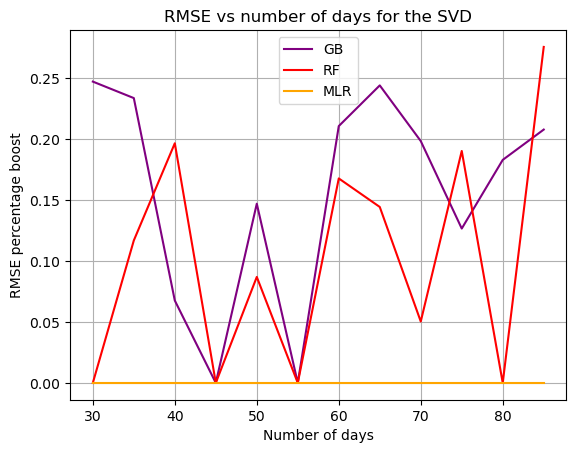

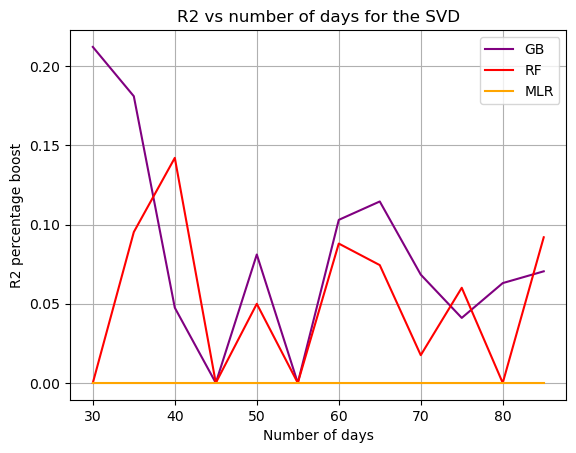

In [2]:
plt.figure()
plt.plot(range(30,90,5), RMSE_precentage_improvement_GB, color='purple',  label="GB")
plt.plot(range(30,90,5), RMSE_precentage_improvement_RF, color='red', label="RF")
plt.plot(range(30,90,5), RMSE_precentage_improvement_MLR, color='orange', label="MLR")
plt.xlabel("Number of days")
plt.ylabel("RMSE percentage boost")
plt.title("RMSE vs number of days for the SVD")
plt.legend()
plt.grid(True)
plt.savefig("images/denoising_RMSE_days.png", dpi=300)
plt.show()

plt.figure()
plt.plot(range(30,90,5), R2_precentage_improvement_GB, color='purple', label="GB")
plt.plot(range(30,90,5), R2_precentage_improvement_RF, color='red', label="RF")
plt.plot(range(30,90,5), R2_precentage_improvement_MLR, color='orange', label="MLR")
plt.xlabel("Number of days")
plt.ylabel("R2 percentage boost")
plt.title("R2 vs number of days for the SVD")
plt.legend()
plt.grid(True)
plt.savefig("images/denoising_R2_days.png", dpi=300)
plt.show()



In [3]:
min(R2_k_mlr)

0.4516601497153403